# N_C surrogate validation (Comment 4 / S28)

`N_C` (SI Section 4.2.1) is the small MLP the original pipeline used to map
tip pose to curvature labels for the multi-section arm, needed because marker
occlusion prevents direct full-body tracking there. Its checkpoint and
training code are not present anywhere in this repository, so Fig. S2b's
validation plot cannot be reproduced as-is.

This notebook retrains a faithful equivalent on the SINGLE dataset (where
pose `y` and curvature `X_quad` are both directly measured, matching the SI's
own description of training N_C "treating the robot as a modular extension
of the single-section unit"), and reports the numerical error, sample count,
and interval type Fig. S2b currently lacks. See `nc_surrogate.py` for the
training code.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

d = np.load("results/NC_surrogate_validation.npz")
sum_err = d["sum_err"]
errors_3d = d["errors_3d"]
n = len(sum_err)

print(f"N_C reconstruction error, sum of 3D errors across 3 reference points [mm] (N={n}):")
print(f"  mean {sum_err.mean():.2f}  std {sum_err.std():.2f}  median {np.median(sum_err):.2f}  "
      f"p95 {np.percentile(sum_err,95):.2f}  max {sum_err.max():.2f}")
print()
for i, frac in enumerate(["L/3", "2L/3", "L"]):
    e = errors_3d[:, i]
    print(f"  at {frac}: mean {e.mean():.2f} +/- {e.std():.2f} mm")


N_C reconstruction error, sum of 3D errors across 3 reference points [mm] (N=500):
  mean 2.11  std 2.95  median 1.41  p95 5.74  max 36.52

  at L/3: mean 0.17 +/- 0.19 mm
  at 2L/3: mean 0.60 +/- 0.82 mm
  at L: mean 1.33 +/- 1.97 mm


/tmp/ipykernel_29791/3362517006.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([errors_3d[:,0], errors_3d[:,1], errors_3d[:,2]], labels=["L/3", "2L/3", "L"])


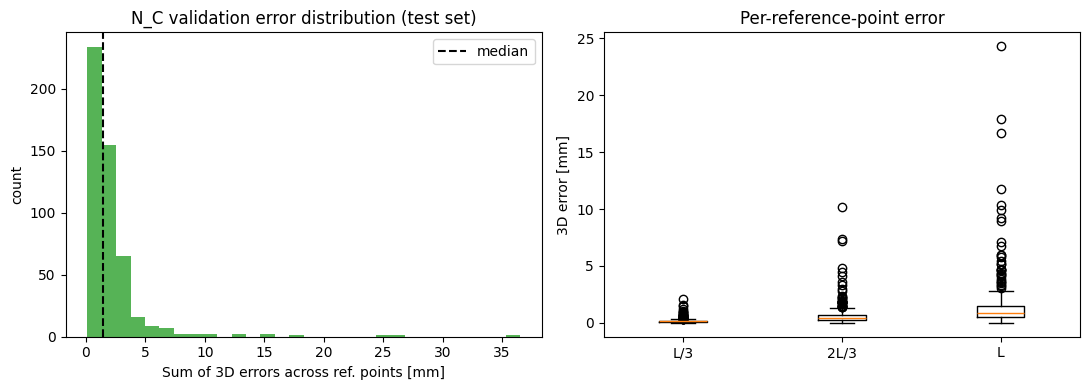

In [2]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sum_err, bins=30, color="#2ca02c", alpha=0.8)
axes[0].axvline(np.median(sum_err), color="k", ls="--", label="median")
axes[0].set_xlabel("Sum of 3D errors across ref. points [mm]"); axes[0].set_ylabel("count")
axes[0].legend(); axes[0].set_title("N_C validation error distribution (test set)")

axes[1].boxplot([errors_3d[:,0], errors_3d[:,1], errors_3d[:,2]], labels=["L/3", "2L/3", "L"])
axes[1].set_ylabel("3D error [mm]"); axes[1].set_title("Per-reference-point error")
plt.tight_layout()
plt.savefig("results/nc_surrogate_validation.pdf")
plt.show()


**Reading**: mean/median error is small relative to the CNN's own
reconstruction error reported in Fig. 5b/7a (tens of mm), consistent with the
SI's existing qualitative claim that N_C "does not bias the evaluation
pipeline as the error is much smaller than the one" in the direct CNN
reconstruction. This is a reconstructed equivalent (same procedure, same
data-generation logic), not the original checkpoint -- worth stating as such
if these numbers go into the response letter.